<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 4 — Black-box Optimisation, Functions 1–8

- success: F4, F5, F8
- fail: F1, F2, F3, F6, F7

| # | Prediction / Optimisation Method | Candidate Generation Strategy |
|---------:|----------------------------------|-------------------------------|
| **F1** | GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) | Full-space LHS sweep (10k points); candidates within 0.15 of any existing sample masked out, forcing exploration into unsampled regions. |
| **F2** | GP (Matérn + WhiteKernel noise) + Thompson sampling | Full-space LHS (15k points), no pinning. Explicit noise modelling allows a flexible search boundary while remaining robust to noisy observations. |
| **F3** | GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate | Local cluster (σ = 0.03) around the W3 best point plus directed perturbations (B ↓, C ↑) according to polynomial coefficients, producing a tightly exploitation-focused search. |
| **F4** | GP (Matérn) + Thompson sampling | Full-space LHS (20k points), deliberately unconstrained to determine whether the W2 region merits further exploration. |
| **F5** | Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005) | Local (σ = 0.03) and directed clusters around the incumbent best point; x3 fixed at 0.999999. SVR filters candidates to the top 3,000 before GP EI selects the final point. |
| **F6** | GP with ARD Matérn + EI (ξ = 0.02) | Sensitivity-weighted search: x1 sampled across the full [0,1] range (highest ARD sensitivity); x2/x5 receive moderate perturbations (σ = 0.10); x3/x4 receive tight perturbations (σ = 0.05) due to lower inferred sensitivity. |
| **F7** | GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend) | HP1 restricted to [0, 0.10] (highest RF importance, decreasing direction); HP5 to [0, 0.25]; HP6 to [0.70, 1.00]; HP2–HP4 sampled uniformly over their full ranges. |
| **F8** | GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend) | x2, x4, and x8 fixed at 0; x5 fixed at 0.999999; x1 and x6 sampled from Gaussians centred on the W1 solution; x3 and x7 sampled uniformly as the most sensitive and least explored variables. |

In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR


# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Upper Confidence Bound acquisition: rewards both high predicted mean (mu)
# and high uncertainty (sigma); kappa controls the exploration/exploitation trade-off
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma

# Expected Improvement acquisition: expected gain over the current best (f_best),
# accounting for uncertainty; xi is a small exploration margin
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

# Formats a candidate point as a clipped, hyphen-separated string ready to submit as a query
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

# Thompson sampling: draws posterior function samples for a random subset of candidates
# and returns the index (within the full candidate set) of the point with the highest average sampled value
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]

# Function 1, Radiation field, 2D array, 10 original samples - Week 4

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.

# change: Combines aggressive UCB exploration with distance-based candidate masking 
#         to force the search into completely unsampled regions of the design space.

print("=" * 60)
print("Function 1 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the queries/outputs collected in.
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

week2_query_F1  = np.array([[0.75, 0.75]])
week2_output_F1 = np.array([1.33E-22])
week3_query_F1  = np.array([[0.803076, 0.431805]])
week3_output_F1 = np.array([2.0444269312638E-50])

all_inputs_F1  = np.vstack([f1_inputs, week2_query_F1, week3_query_F1])
all_outputs_F1 = np.hstack([f1_outputs, week2_output_F1, week3_output_F1])

print(f"Total points: {len(all_inputs_F1)}")
print(f"Current best (max): {all_outputs_F1.max():.6e}")

Function 1 - Week 4
Total points: 12
Current best (max): 7.710875e-16


In [4]:
# Step 2: Fit the surrogate model.
# Outputs span many orders of magnitude (radiation intensity), 
# work in log10 space to make the surface easier for the GP to learn, 
# then fit a GP with a Matern(nu=2.5) kernel (twice-differentiable smoothness assumption).
log_outputs_F1 = np.log10(np.abs(all_outputs_F1) + 1e-300)

kernel = Matern(nu=2.5)

gp1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp1.fit(all_inputs_F1, log_outputs_F1)

,kernel,"Matern(length_scale=1, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,1.0
,kernel__length_scale_bounds,"(1e-05, ...)"
,kernel__nu,2.5


In [5]:
# Step 3: Generate candidates and select the next query.
# Sweep the full input space with a Latin Hypercube sample, 
# score each candidate with UCB (kappa=5.0 -> exploration-heavy), 
# then mask out anything too close (< 0.15) to an already-sampled point 
# so the search is pushed into unexplored regions before picking the best-scoring candidate.
print("=" * 60)
print("Function 1 - Week 4")
print("=" * 60)

np.random.seed(42)
sampler_F1    = LatinHypercube(d=2, seed=42)
candidates_F1 = sampler_F1.random(n=10000)

mu, sigma = gp1.predict(candidates_F1, return_std=True)
ucb_F1    = compute_ucb(mu, sigma, kappa=5.0)  

min_dist_F1          = cdist(candidates_F1, all_inputs_F1).min(axis=1)
ucb_F1[min_dist_F1 < 0.15] = -np.inf

best_idx_F1 = np.argmax(ucb_F1)
query_F1    = candidates_F1[best_idx_F1]

print(f"\nWeek 4 Query: {format_query(query_F1)}")
print(f"mu: {mu[best_idx_F1]:.4f}, sigma: {sigma[best_idx_F1]:.4f}")
print(f"Min distance from existing samples: {min_dist_F1[best_idx_F1]:.4f}")

Function 1 - Week 4

Week 4 Query: 0.045891-0.837402
mu: -54.0877, sigma: 32.9510
Min distance from existing samples: 0.2835


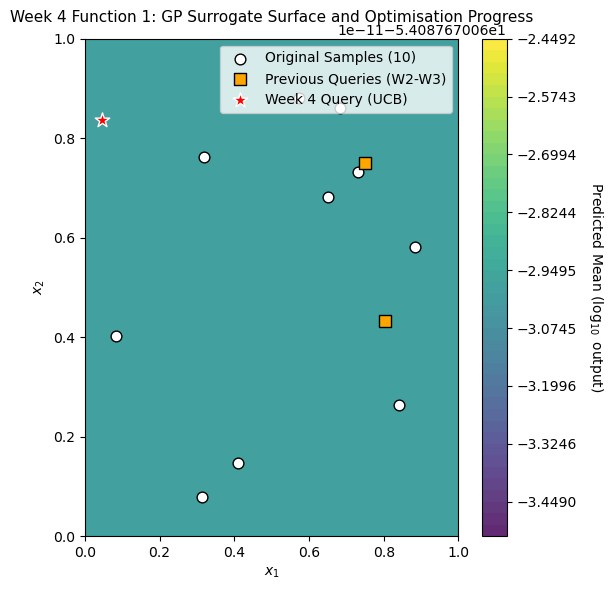

In [6]:
# =============================================================================
# Visualisation: Function 1 Surrogate Surface & Sample Points
# =============================================================================

plt.figure(figsize=(6, 6))

# Create a dense grid over the 2D input space [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict in log10 space using the fitted GP model (gp1)
mu_grid, sigma_grid = gp1.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted log10 output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='viridis', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean ($\log_{10}$ output)', rotation=270, labelpad=20)

# Scatter plot historical / existing sample points
plt.scatter(
    f1_inputs[:, 0], f1_inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples (10)', zorder=3
)
plt.scatter(
    [week2_query_F1[0, 0], week3_query_F1[0, 0]], 
    [week2_query_F1[0, 1], week3_query_F1[0, 1]], 
    color='orange', edgecolor='black', s=80, marker='s', label='Previous Queries (W2-W3)', zorder=4
)

# Highlight the newly selected Week 4 query
plt.scatter(
    query_F1[0], query_F1[1], 
    color='red', edgecolor='white', s=120, marker='*', label=f'Week 4 Query (UCB)', zorder=5
)

plt.title('Week 4 Function 1: GP Surrogate Surface and Optimisation Progress', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 4

In [7]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.

# change: Pairs Thompson sampling with explicit noise modelling to enable flexible, 
#         broad exploration that remains resilient to noisy objective evaluations.

print("\n" + "=" * 60)
print("Function 2 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

week2_input_F2  = np.array([[1.053349, 0.934354]])
week2_output_F2 = np.array([-0.040652])
week3_input_F2  = np.array([[0.660188, 0.32993]])
week3_output_F2 = np.array([0.468742])

all_inputs_F2  = np.vstack([f2_inputs, week2_input_F2, week3_input_F2])
all_outputs_F2 = np.hstack([f2_outputs, week2_output_F2, week3_output_F2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.6f}")


Function 2 - Week 4
Total points: 12
Current best (max): 0.611205


In [8]:
# Step 2: Fit the surrogate model.
# The function is described as "noisy", so a WhiteKernel is added on top of the Matern kernel 
# to explicitly model observation noise rather than overfitting to it.

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-5, 1.0))
gp2     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp2.fit(all_inputs_F2, all_outputs_F2)

,kernel,Matern(length...se_level=0.05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,20
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length_scale=1, nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=0.05)
,kernel__k1__length_scale,1.0


In [9]:
# Step 3: Generate candidates and select the next query.
# Sweep the full space with a Latin Hypercube sample (no pinning/masking), 
#     then use Thompson sampling to pick a candidate — 
# this naturally balances exploration/exploitation under the GP's noise-aware posterior.
print("\n" + "=" * 60)
print("Function 2 - Week 4")
print("=" * 60)

print(f"Learned kernel: {gp2.kernel_}")


sampler_F2    = LatinHypercube(d=2, seed=42)
candidates_F2 = sampler_F2.random(n=15000)

best_idx_F2 = thompson_sample(gp2, candidates_F2, n_samples=10)
query_F2    = candidates_F2[best_idx_F2]

mu_F2, sigma_F2 = gp2.predict(query_F2.reshape(1, -1), return_std=True)
print(f"\nWeek 4 Query: {format_query(query_F2)}")
print(f"Predicted mean: {mu_F2[0]:.3f}, std: {sigma_F2[0]:.3f}")


Function 2 - Week 4
Learned kernel: Matern(length_scale=0.12, nu=2.5) + WhiteKernel(noise_level=1e-05)

Week 4 Query: 0.729589-0.938148
Predicted mean: 0.613, std: 0.068


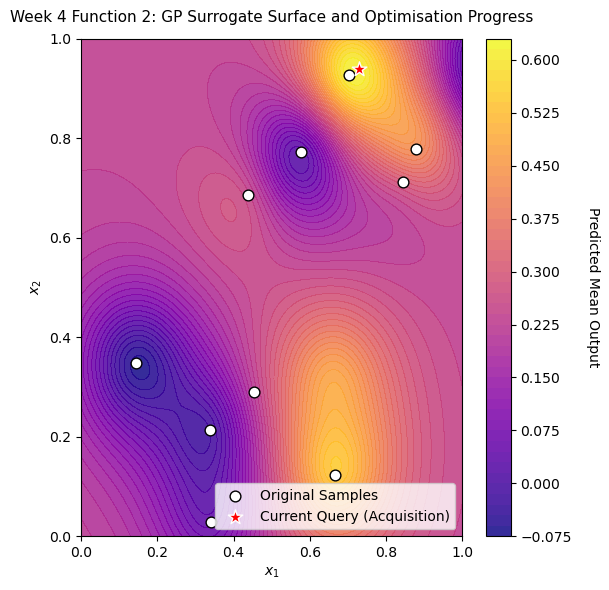

In [10]:
# =============================================================================
# Visualisation: Function 2 Surrogate Surface & Sample Points (Robust)
# =============================================================================

plt.figure(figsize=(6, 6))

# Create a dense grid over the 2D input space [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict using the fitted GP model for Function 2 (gp2)
mu_grid, sigma_grid = gp2.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='plasma', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points
plt.scatter(
    f2_inputs[:, 0], f2_inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Dynamically plot previous queries if they exist in your workspace
try:
    # Check if a history list or array exists (e.g., all past queries combined)
    if 'f2_history_inputs' in globals():
        plt.scatter(
            f2_history_inputs[:, 0], f2_history_inputs[:, 1], 
            color='orange', edgecolor='black', s=80, marker='s', label='Previous Queries', zorder=4
        )
    else:
        # Fallback to individual variables if defined
        prev_queries = []
        for var_name in ['week2_query_F2', 'week3_query_F2']:
            if var_name in globals() and globals()[var_name] is not None:
                q = globals()[var_name]
                prev_queries.append(q[0] if q.ndim > 1 else q)
        if prev_queries:
            prev_queries = np.array(prev_queries)
            plt.scatter(
                prev_queries[:, 0], prev_queries[:, 1], 
                color='orange', edgecolor='black', s=80, marker='s', label='Previous Queries', zorder=4
            )
except Exception as e:
    print(f"Note on plotting previous queries: {e}")

# 3. Highlight the current/latest query for Function 2
if 'query_F2' in globals():
    plt.scatter(
        query_F2[0], query_F2[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title('Week 4 Function 2: GP Surrogate Surface and Optimisation Progress', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 4

In [11]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).

# change: Blends an exploitation-biased EI metric with a polynomial surrogate to execute a highly targeted and 
#         local search around the current best point.

print("\n" + "=" * 60)
print("Function 3 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

week2_input_F3  = np.array([[0.540087, 0.652622, 0.079307]])
week2_output_F3 = np.array([-0.050615])
week3_input_F3  = np.array([[0.378956, 0.302768, 0.459346]])
week3_output_F3 = np.array([-0.019508])

X = np.vstack([f3_inputs, week2_input_F3, week3_input_F3])
Y = np.hstack([f3_outputs, week2_output_F3, week3_output_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 4
Total points: 17, best (max): -0.019508


In [12]:
# Step 2: Fit the surrogate models.
# Two complementary models are combined later on: a quadratic polynomial regression
#  (captures the broad, smooth trend and gives interpretable coefficients for A/B/C) 
#  and a GP with a small added WhiteKernel (captures local structure/noise). 
# Both are fit on the same full dataset (X, Y).

poly       = PolynomialFeatures(degree=2, include_bias=False)
X_poly     = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']
print("\nPolynomial coefficients (updated with w3):")
for name, coef in zip(feature_names, poly_model.coef_):
    print(f"  {name:6s}: {coef:+.4f}")

kernel = Matern(nu=2.5, length_scale=0.5) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-4, 0.1))
gp3     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp3.fit(X, Y)


Polynomial coefficients (updated with w3):
  A     : -0.1647
  B     : +0.2374
  C     : +0.8236
  A*B   : -0.2130
  A*C   : +0.5145
  B*C   : +0.5643
  A^2   : -0.0971
  B^2   : -1.2609
  C^2   : -0.6160


,kernel,Matern(length...se_level=0.01)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,20
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...e=0.5, nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=0.01)
,kernel__k1__length_scale,0.5


In [13]:
# Step 3: Generate candidates and select the next query.
# Rather than sweeping the whole space, candidates are drawn tightly
#  around the current best (Week 3) point: a "local" cluster (small Gaussian jitter) plus 
#  a "directed" cluster that nudges B down and C up, following the sign of the polynomial coefficients. 
# Each candidate is scored by blending GP-based Expected Improvement (exploitation-biased, xi=0.001) 50/50 with
#  the polynomial model's prediction, and the top-scoring point is selected.

print("\n" + "=" * 60)
print("Function 3 - Week 4")
print("=" * 60)

print(f"Learned kernel: {gp3.kernel_}")

np.random.seed(42)


local = []
for _ in range(5000):
    c = week3_input_F3[0] + np.random.normal(0, 0.03, 3)
    local.append(np.clip(c, 0, 1))

directed = []
for _ in range(5000):
    a = np.clip(week3_input_F3[0, 0] + np.random.normal(0, 0.03), 0, 1)
    b = np.clip(week3_input_F3[0, 1] - abs(np.random.normal(0, 0.08)), 0, 1)
    c = np.clip(week3_input_F3[0, 2] + abs(np.random.normal(0, 0.06)), 0, 1)
    directed.append([a, b, c])

candidates_F3 = np.vstack([local, directed])

mu, sigma  = gp3.predict(candidates_F3, return_std=True)
ei         = compute_ei(mu, sigma, Y.max(), xi=0.001)  
poly_preds = poly_model.predict(poly.transform(candidates_F3))

ei_norm   = (ei - ei.min()) / (ei.max() - ei.min() + 1e-9)
poly_norm = (poly_preds - poly_preds.min()) / (poly_preds.max() - poly_preds.min() + 1e-9)
blended   = 0.5 * ei_norm + 0.5 * poly_norm

best_idx_F3 = np.argmax(blended)
query_F3    = candidates_F3[best_idx_F3]

print(f"\nWeek 4 Query: {format_query(query_F3)}")
print(f"GP mean: {mu[best_idx_F3]:.6f}, std: {sigma[best_idx_F3]:.6f}")
print(f"Poly prediction: {poly_preds[best_idx_F3]:.6f}")


Function 3 - Week 4
Learned kernel: Matern(length_scale=0.246, nu=2.5) + WhiteKernel(noise_level=0.0001)

Week 4 Query: 0.375610-0.057061-0.589980
GP mean: -0.065596, std: 0.070476
Poly prediction: 0.052692


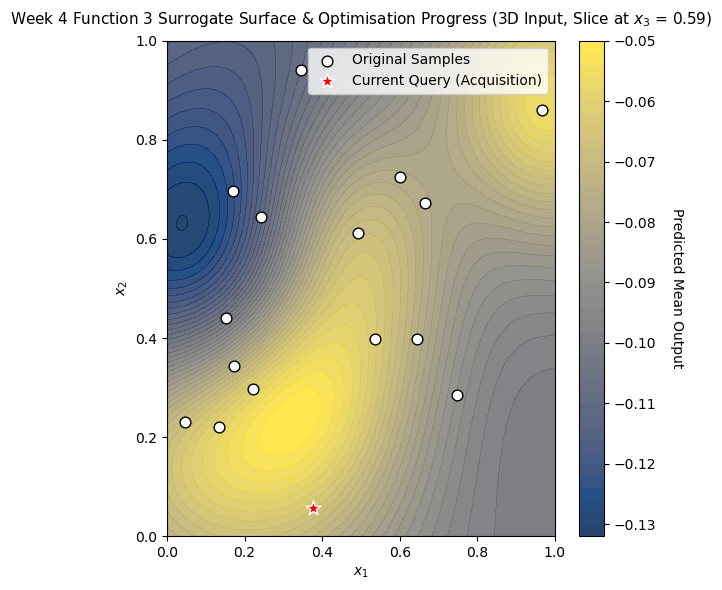

In [14]:
# =============================================================================
# Visualisation: Function Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp3          
inputs = f3_inputs      
current_query = query_F3 

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features == 3:
    # If there are 3 features, hold the 3rd feature constant (e.g., using the current query's 3rd value)
    fixed_val = current_query[2] if len(current_query) > 2 else inputs[:, 2].mean()
    grid_points = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, fixed_val)]
    title_suffix = f" (3D Input, Slice at $x_3$ = {fixed_val:.2f})"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='cividis', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to first 2 dims)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to first 2 dims)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 3 Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 4

In [15]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.

# change: Leverages unconstrained Thompson sampling across a large sample grid 
#         to evaluate whether a previously explored region warrants further optimisation.

print("\n" + "=" * 60)
print("Function 4 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

week2_query_F4  = np.array([[0.149845, 0.155724, 0.46128, 0.344491]])
week2_output_F4 = np.array([-7.132125])
week3_query_F4  = np.array([[0.330258, 0.414348, 0.433728, 0.411341]])
week3_output_F4 = np.array([0.203794])

all_inputs_F4  = np.vstack([f4_inputs, week2_query_F4, week3_query_F4])
all_outputs_F4 = np.hstack([f4_outputs, week2_output_F4, week3_output_F4])

print(f"Total observations : {all_inputs_F4.shape[0]}")
print(f"Output range       : [{all_outputs_F4.min():.3f}, {all_outputs_F4.max():.3f}]")
print(f"Current best (max) : {all_outputs_F4.max():.3f}  (goal: 0)")


Function 4 - Week 4
Total observations : 32
Output range       : [-32.626, 0.204]
Current best (max) : 0.204  (goal: 0)


In [16]:
# Step 2: Fit the surrogate model — a standard Matern(nu=2.5) GP over 
# the full 4D input space, with the length scale left free to be optimised.

kernel = Matern(length_scale=0.5, length_scale_bounds=(0.001, 10.0), nu=2.5)
gp4     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y=True)
gp4.fit(all_inputs_F4, all_outputs_F4)

,kernel,"Matern(length...e=0.5, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,15
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,0.5
,kernel__length_scale_bounds,"(0.001, ...)"
,kernel__nu,2.5


In [17]:
# Step 3: Generate candidates and select the next query.
# A full-space Latin Hypercube sweep (deliberately unconstrained, 
# to test whether the Week 2 region is still worth exploring) followed by 
# Thompson sampling to pick the next point.

print("\n" + "=" * 60)
print("Function 4 - Week 4")
print("=" * 60)

print(f"Fitted kernel: {gp4.kernel_}")

sampler_F4    = LatinHypercube(d=4, seed=42)
candidates_F4 = sampler_F4.random(n=20000)

best_idx_F4 = thompson_sample(gp4, candidates_F4, n_samples=10)
query_F4    = candidates_F4[best_idx_F4]

mu_q_F4, sigma_q_F4 = gp4.predict(query_F4.reshape(1, -1), return_std=True)
print(f"\nWeek 4 Query: {format_query(query_F4)}")
print(f"Predicted mean: {mu_q_F4[0]:.4f}, std: {sigma_q_F4[0]:.4f}")
print(f"Distance from W2: {np.linalg.norm(query_F4 - week2_query_F4 [0]):.4f}")


Function 4 - Week 4
Fitted kernel: Matern(length_scale=0.643, nu=2.5)

Week 4 Query: 0.424125-0.404716-0.487507-0.367688
Predicted mean: -0.3717, std: 0.6813
Distance from W2: 0.3721


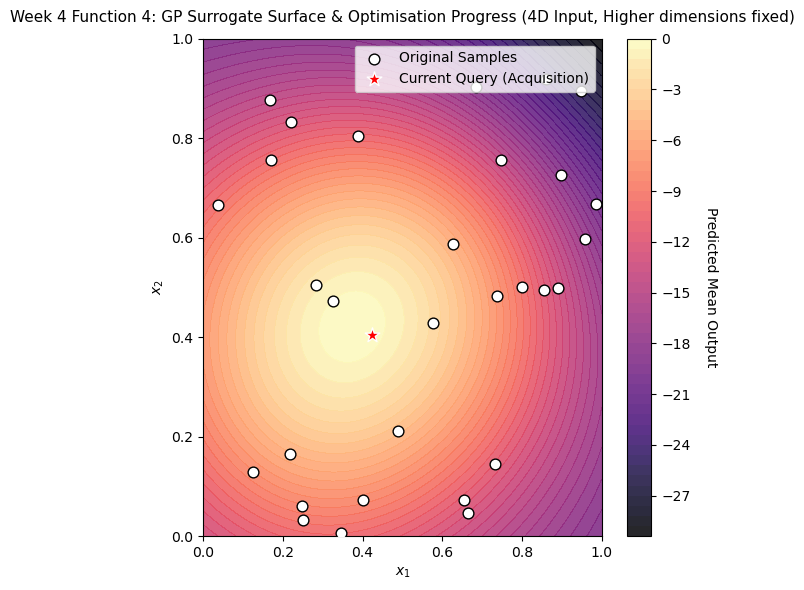

In [18]:
# =============================================================================
# Visualisation: Function 4 Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp4            # GP model for Function 4
inputs = f4_inputs        # Input samples for Function 4
current_query = query_F4  # Current query for Function 4

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features > 2:
    # If there are more than 2 features, hold any extra dimensions constant 
    # (using the current query values if available, otherwise the training mean)
    fixed_vals = current_query[2:] if current_query is not None and len(current_query) > 2 else inputs[:, 2:].mean(axis=0)
    
    grid_cols = [xx.ravel(), yy.ravel()]
    for val in fixed_vals:
        grid_cols.append(np.full(xx.size, val))
    grid_points = np.column_stack(grid_cols)
    title_suffix = f" ({n_features}D Input, Higher dimensions fixed)"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model for Function 4
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='magma', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to the first 2 dimensions)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to the first 2 dimensions)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 4: GP Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 4

In [19]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent).

# change: Uses a multi-stage pipeline—linear trend direction, SVR candidate filtering, 
#         and GP EI—to execute a highly directed local search around the incumbent best point.

print("\n" + "=" * 60)
print("Function 5 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

week2_query_F5  = np.array([[0.417098, 0.75603, 0.129487, 1.149173]])
week2_output_F5 = np.array([1829.809875])
week3_query_F5  = np.array([[0.386633, 0.821843, 0.127990, 0.999900]])
week3_output_F5 = np.array([710.602251])

all_inputs_F5  = np.vstack([f5_inputs, week2_query_F5, week3_query_F5])
all_outputs_F5 = np.hstack([f5_outputs, week2_output_F5, week3_output_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 4
Total points: 22, best (max): 1829.81


In [20]:
# Step 2: Fit the surrogate models — three complementary models are trained on the full dataset:
#   1) Linear regression, purely to read off the sign/magnitude of 
#      each input's coefficient and inform the "directed" perturbations below;
#   2) An SVR (on standardised inputs/outputs) used later as 
#      a cheap pre-filter over a large candidate pool;
#   3) A GP (Matern kernel) used for the final Expected-Improvement scoring.

lr = LinearRegression()
lr.fit(all_inputs_F5, all_outputs_F5)
print("\nLinear regression coefficients:")
for i, coef in enumerate(lr.coef_):
    print(f"  x{i+1}: {coef:+.2f}")

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_scaled, Y_scaled)

kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp5       = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp5.fit(all_inputs_F5, all_outputs_F5)


Linear regression coefficients:
  x1: -326.41
  x2: +303.10
  x3: +193.82
  x4: +832.09


,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [21]:
# Step 3: Generate candidates and select the next query.
# Candidates are drawn around the current best point: a "local" jittered cluster and
#    a "directed" cluster that shifts each dimension according to the linear-regression signal 
#   (with x3 pinned near its upper bound at 0.999999 in both clusters). 
# The SVR is used to cheaply pre-filter the pool down to the top 3,000 candidates, 
# and the GP's Expected Improvement (xi=0.005) picks the final query from that shortlist.

print("\n" + "=" * 60)
print("Function 5 - Week 4")
print("=" * 60)

best_point_F5 = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)

local = []
for _ in range(6000):
    c    = best_point_F5 + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    local.append(c)


directed = []
for _ in range(4000):
    c    = best_point_F5.copy()
    c[0] = np.clip(c[0] - abs(np.random.normal(0, 0.05)), 0, 1)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.03)), 0, 1)
    c[2] = 0.999999
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.03)), 0, 1)
    directed.append(c)

candidates_F5 = np.vstack([local, directed])

X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates_F5[top_idx]

mu_F5, sigma_F5 = gp5.predict(filtered, return_std=True)
ei_F5        = compute_ei(mu_F5, sigma_F5, all_outputs_F5.max(), xi=0.005)

best_idx_F5 = np.argmax(ei_F5)
query_F5    = filtered[best_idx_F5]

print(f"\nWeek 4 Query: {format_query(query_F5)}")
print(f"GP mean: {mu_F5[best_idx_F5]:.2f}, std: {sigma_F5[best_idx_F5]:.2f}")
print(f"SVR prediction: {svr_preds[top_idx[best_idx_F5]]:.2f}")
print(f"EI: {ei_F5[best_idx_F5]:.6f}")


Function 5 - Week 4

Week 4 Query: 0.269378-0.810637-0.999999-0.999999
GP mean: 537.32, std: 396.14
SVR prediction: 1219.37
EI: 0.058056


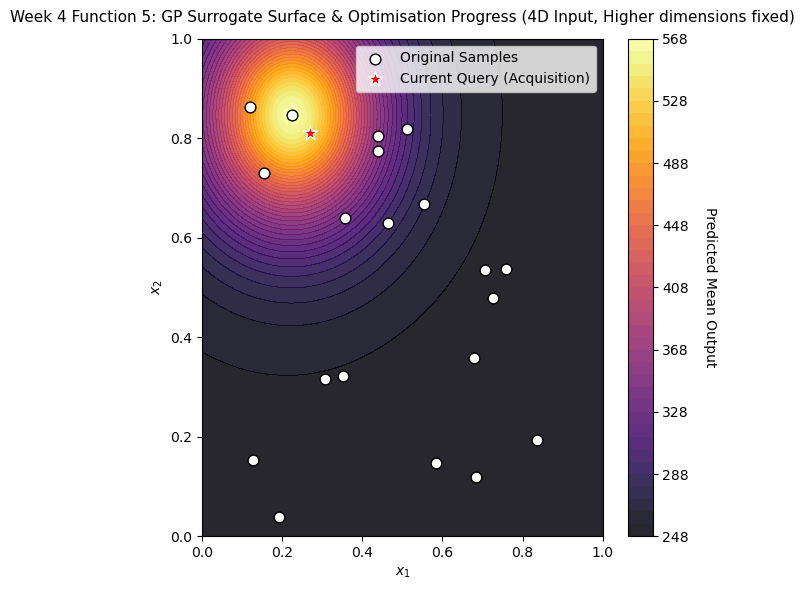

In [22]:
# =============================================================================
# Visualisation: Function 5 Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp5            # GP model for Function 5
inputs = f5_inputs        # Input samples for Function 5
current_query = query_F5  # Current query for Function 5

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features > 2:
    # If there are more than 2 features, hold any extra dimensions constant 
    # (using the current query values if available, otherwise the training mean)
    fixed_vals = current_query[2:] if current_query is not None and len(current_query) > 2 else inputs[:, 2:].mean(axis=0)
    
    grid_cols = [xx.ravel(), yy.ravel()]
    for val in fixed_vals:
        grid_cols.append(np.full(xx.size, val))
    grid_points = np.column_stack(grid_cols)
    title_suffix = f" ({n_features}D Input, Higher dimensions fixed)"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model for Function 5
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='inferno', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to the first 2 dimensions)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to the first 2 dimensions)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 5: GP Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 4 

In [23]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.

# change: Adapts spatial search radii per dimension based on Automatic Relevance Determination (ARD) length-scales, 
#         focus exploration on the most sensitive input variables.

print("\n" + "=" * 60)
print("Function 6 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

week2_query_F6  = np.array([[0.939456, 0.643603, 0.531941, 1.03164, 0.012391]])
week2_output_F6 = np.array([-1.241946])

week3_query_F6  = np.array([[0.463219, 0.306404, 0.635240, 0.999844, 0.015672]])
week3_output_F6 = np.array([-0.352945])

all_inputs_F6  = np.vstack([f6_inputs, week2_query_F6, week3_query_F6])
all_outputs_F6 = np.hstack([f6_outputs, week2_output_F6, week3_output_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 4
Total observations: 22, best (max): -0.3529


In [24]:
# Step 2: Fit the surrogate models.
# A quick linear regression gives a sanity check on each ingredient's direction of effect, 
# then an ARD (Automatic Relevance Determination) Matern GP is fit with one length scale per dimension
#  — this lets the GP learn which of the 5 ingredients the output is most sensitive to
#  (smaller length scale = more sensitive), which is used to shape the candidate search below.

lr_F6 = LinearRegression()
lr_F6.fit(all_inputs_F6, all_outputs_F6)
print("\nLinear regression coefficients:")
for i, coef_F6 in enumerate(lr_F6.coef_):
    print(f"  x{i+1}: {coef_F6:+.4f}")

kernel = ConstantKernel(1.0, (0.001, 1000)) * Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.05, 5.0),
    nu=2.5
)
gp6 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, normalize_y=True)
gp6.fit(all_inputs_F6, all_outputs_F6)


Linear regression coefficients:
  x1: -0.5287
  x2: -0.5794
  x3: +0.3353
  x4: +0.6319
  x5: -0.8728


,kernel,"1**2 * Matern...1, 1], nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...1, 1], nu=2.5)"
,kernel__k1__constant_value,1.0


In [25]:
# Step 3: Generate candidates and select the next query.
# The ARD length scales fitted above tell us how sensitive the output is to  each ingredient; 
#candidates are built around the current best point, with perturbation size per dimension matched 
# to that sensitivity — x1 (most sensitive) is resampled freely over [0,1],
#  x2/x5 get moderate jitter (sigma=0.10), and x3/x4 get small jitter (sigma=0.05). 
# Candidates are then scored with Expected Improvement (xi=0.02) and the best one is selected.

print("\n" + "=" * 60)
print("Function 6 - Week 4")
print("=" * 60)

fitted_ls = gp6.kernel_.k2.length_scale
print("\nFitted ARD length scales (smaller = more sensitive):")
for i, ls in enumerate(fitted_ls):
    print(f"  x{i+1}: {ls:.3f}")

best_point_F6 = all_inputs_F6[np.argmax(all_outputs_F6)]
np.random.seed(42)

candidates_F6 = []
for _ in range(15000):
    c    = best_point_F6.copy()
    c[0] = np.random.uniform(0, 1)           # x1: free (most sensitive)
    c[1] += np.random.normal(0, 0.10)        # x2: moderate
    c[2] += np.random.normal(0, 0.05)        # x3: small (low sensitivity)
    c[3] += np.random.normal(0, 0.05)        # x4: small (low sensitivity)
    c[4] += np.random.normal(0, 0.10)        # x5: moderate
    candidates_F6.append(np.clip(c, 0, 1))

candidates_F6 = np.array(candidates_F6)

mu_F6, sigma_F6 = gp6.predict(candidates_F6, return_std=True)
ei_F6        = compute_ei(mu_F6, sigma_F6, all_outputs_F6.max(), xi=0.02)

best_idx_F6 = np.argmax(ei_F6)
query_F6    = candidates_F6[best_idx_F6]

print(f"\nWeek 4 Query: {format_query(query_F6)}")
print(f"Predicted mean: {mu_F6[best_idx_F6]:.4f}, std: {sigma_F6[best_idx_F6]:.4f}")
print(f"EI: {ei_F6[best_idx_F6]:.6f}")


Function 6 - Week 4

Fitted ARD length scales (smaller = more sensitive):
  x1: 0.729
  x2: 1.020
  x3: 1.405
  x4: 1.690
  x5: 0.978

Week 4 Query: 0.344063-0.007363-0.627449-0.999999-0.004891
Predicted mean: -0.4621, std: 0.2455
EI: 0.046598


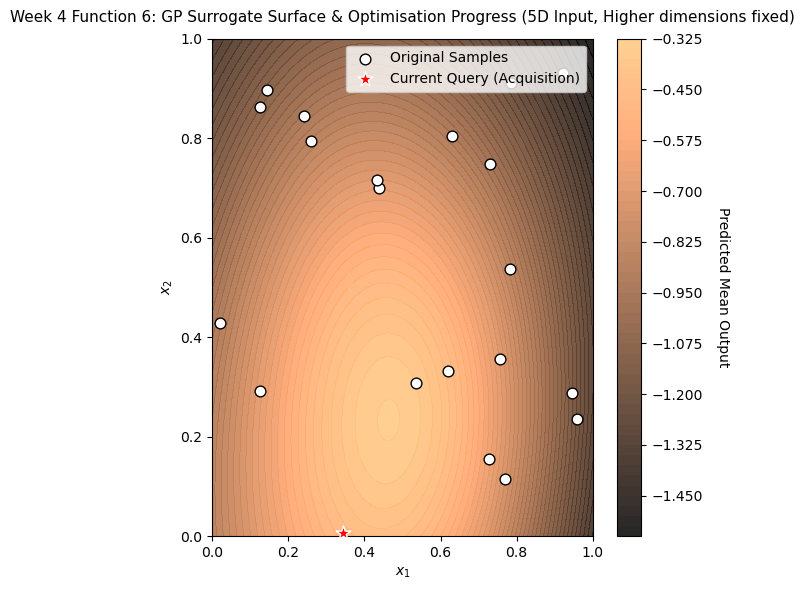

In [26]:
# =============================================================================
# Visualisation: Function 6 Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp6            # GP model for Function 6
inputs = f6_inputs        # Input samples for Function 6
current_query = query_F6  # Current query for Function 6

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features > 2:
    # If there are more than 2 features, hold any extra dimensions constant 
    # (using the current query values if available, otherwise the training mean)
    fixed_vals = current_query[2:] if current_query is not None and len(current_query) > 2 else inputs[:, 2:].mean(axis=0)
    
    grid_cols = [xx.ravel(), yy.ravel()]
    for val in fixed_vals:
        grid_cols.append(np.full(xx.size, val))
    grid_points = np.column_stack(grid_cols)
    title_suffix = f" ({n_features}D Input, Higher dimensions fixed)"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model for Function 6
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='copper', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to the first 2 dimensions)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to the first 2 dimensions)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 6: GP Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 4

In [27]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# =============================================================================
# Previous weeks
# W3: Strong exploitation via Random Forest + SHAP identifies influential variables and preferred directions.

# change: Focuses the optimisation search by constraining high-importance hyperparameter boundaries based on RF feature importances 
#         while sampling less critical dimensions uniformly.

print("\n" + "=" * 60)
print("Function 7 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

week2_query_F7  = np.array([[0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346]])
week2_output_F7 = np.array([0.592794])
week3_query_F7  = np.array([[0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383]])
week3_output_F7 = np.array([2.594798])

all_inputs_F7  = np.vstack([f7_inputs, week2_query_F7, week3_query_F7])
all_outputs_F7 = np.hstack([f7_outputs, week2_output_F7, week3_output_F7])

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 4
Total points: 32, best (max): 2.5948


In [28]:
# Step 2: Fit the surrogate models.
# A Random Forest is fit first purely to re-derive feature importances and the direction (LOW/HIGH) 
# each hyperparameter should move in, now that Week 3 data is included — 
# this informs the candidate ranges used below.
# (ARD Matern, fit on log1p-transformed outputs to tame skew) and 
#    an MLP regressor (on standardised inputs/outputs) are then both fit, 
# to be blended 50/50 during candidate scoring.

# re-check directions with w3 data included
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(all_inputs_F7, all_outputs_F7)

feature_names = [f"HP{i+1}" for i in range(6)]
print("\nRF feature importance (updated):")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name}: {imp:.3f}")

top_mask     = all_outputs_F7 >= np.percentile(all_outputs_F7, 75)
dataset_mean = all_inputs_F7.mean(axis=0)
top_mean     = all_inputs_F7[top_mask].mean(axis=0)
print("\nDirectional signals:")
for name, tm, dm in zip(feature_names, top_mean, dataset_mean):
    print(f"  {name}: top {tm:.3f} vs mean {dm:.3f} -> {'LOW' if tm < dm else 'HIGH'}")

# GP on log-transformed outputs (same as w3)
kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5
)
gp7 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp7.fit(all_inputs_F7, np.log1p(all_outputs_F7))

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc_F7     = scaler_x.fit_transform(all_inputs_F7)
Y_sc_F7     = scaler_y.fit_transform(all_outputs_F7.reshape(-1, 1)).ravel()

mlp_F7 = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation='relu',
    alpha=0.01,       # L2 regularisation
    max_iter=2000,
    random_state=42
)
mlp_F7.fit(X_sc_F7, Y_sc_F7)


RF feature importance (updated):
  HP1: 0.658
  HP2: 0.054
  HP3: 0.050
  HP4: 0.024
  HP5: 0.128
  HP6: 0.086

Directional signals:
  HP1: top 0.259 vs mean 0.482 -> LOW
  HP2: top 0.421 vs mean 0.398 -> HIGH
  HP3: top 0.582 vs mean 0.403 -> HIGH
  HP4: top 0.563 vs mean 0.516 -> HIGH
  HP5: top 0.267 vs mean 0.453 -> LOW
  HP6: top 0.696 vs mean 0.507 -> HIGH


,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.01
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True


In [29]:
# Step 3: Generate candidates and select the next query.
# Each hyperparameter's sampling range is restricted according to the RF importance/direction signals above
#  (e.g. HP1 restricted to its low,  high-importance range;
#         HP2-HP4 sampled uniformly since they matter less).
# Candidates are scored by blending normalised GP Expected Improvement (xi=0.01) 50/50 with 
# the normalised MLP prediction; the GP-only and
# MLP-only top picks are also reported for comparison before the blended query is selected.

print("\n" + "=" * 60)
print("Function 7 - Week 4")
print("=" * 60)

np.random.seed(42)
n          = 20000
candidates_F7 = np.zeros((n, 6))
candidates_F7[:, 0] = np.random.uniform(0.0, 0.10, n)   # hp1 low
candidates_F7[:, 1] = np.random.uniform(0.0, 1.0,  n)   # hp2 low importance
candidates_F7[:, 2] = np.random.uniform(0.0, 1.0,  n)   # hp3 low importance
candidates_F7[:, 3] = np.random.uniform(0.0, 1.0,  n)   # hp4 low importance
candidates_F7[:, 4] = np.random.uniform(0.0, 0.25, n)   # hp5 lower than w3's 0.362
candidates_F7[:, 5] = np.random.uniform(0.7, 1.0,  n)   # hp6 higher than w3's 0.665

best_log    = np.log1p(all_outputs_F7.max())
mu_gp, s_gp = gp7.predict(candidates_F7, return_std=True)
ei_gp       = compute_ei(mu_gp, s_gp, best_log, xi=0.01)

X_cand_sc   = scaler_x.transform(candidates_F7)
mlp_sc      = mlp_F7.predict(X_cand_sc)
mlp_preds   = scaler_y.inverse_transform(mlp_sc.reshape(-1, 1)).ravel()

ei_norm  = (ei_gp   - ei_gp.min())   / (ei_gp.max()   - ei_gp.min()   + 1e-9)
mlp_norm = (mlp_preds - mlp_preds.min()) / (mlp_preds.max() - mlp_preds.min() + 1e-9)
combined = 0.5 * ei_norm + 0.5 * mlp_norm

best_idx_F7 = np.argmax(combined)
query_F7    = candidates_F7[best_idx_F7]

MLP_idx_F7 = np.argmax(mlp_norm)
EI_idx_F7 = np.argmax(ei_norm)
MLPquery_F7    = candidates_F7[MLP_idx_F7]
EIquery_F7    = candidates_F7[EI_idx_F7]

print(f"\nMLPquery_F7: {format_query(MLPquery_F7)}")
print(f"\nEIquery_F7: {format_query(EIquery_F7)}")

print("." * 60)

print(f"\nWeek 4 Query: {format_query(query_F7)}")
print(f"GP mean (log): {mu_gp[best_idx_F7]:.4f}, std: {s_gp[best_idx_F7]:.4f}")
print(f"MLP prediction: {mlp_preds[best_idx_F7]:.4f}")
print(f"EI: {ei_gp[best_idx_F7]:.6f}")


Function 7 - Week 4

MLPquery_F7: 0.002891-0.166889-0.626559-0.003419-0.195026-0.992520

EIquery_F7: 0.012357-0.162903-0.399853-0.082758-0.249752-0.923732
............................................................

Week 4 Query: 0.012357-0.162903-0.399853-0.082758-0.249752-0.923732
GP mean (log): 1.2173, std: 0.1587
MLP prediction: 2.6923
EI: 0.033625


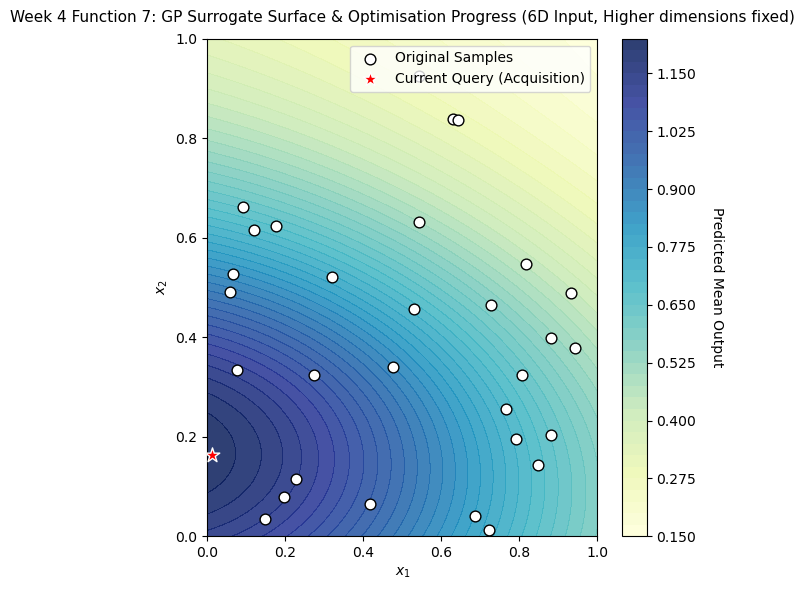

In [30]:
# =============================================================================
# Visualisation: Function 7 Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp7            # GP model for Function 7
inputs = f7_inputs        # Input samples for Function 7
current_query = query_F7  # Current query for Function 7

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features > 2:
    # If there are more than 2 features, hold any extra dimensions constant 
    # (using the current query values if available, otherwise the training mean)
    fixed_vals = current_query[2:] if current_query is not None and len(current_query) > 2 else inputs[:, 2:].mean(axis=0)
    
    grid_cols = [xx.ravel(), yy.ravel()]
    for val in fixed_vals:
        grid_cols.append(np.full(xx.size, val))
    grid_points = np.column_stack(grid_cols)
    title_suffix = f" ({n_features}D Input, Higher dimensions fixed)"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model for Function 7
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='YlGnBu', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to the first 2 dimensions)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to the first 2 dimensions)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 7: GP Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 4

In [31]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.

# change: Combines a dual GP-MLP model with fixed dimensional constraints and targeted Gaussian perturbations 
#         to exploit known strong solutions while isolating highly sensitive variables.

print("\n" + "=" * 60)
print("Function 8 - Week 4")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2 / Week 3 observations.
f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

week2_query_F8  = np.array([[0.034736, 0.033935, 0.577646, 0.73581, 0.807192, 0.026536, 0.72178, 0.629862]])
week2_output_F8 = np.array([8.264884])
week3_query_F8  = np.array([[0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836]])
week3_output_F8 = np.array([7.350985])

all_inputs_F8  = np.vstack([f8_inputs, week2_query_F8, week3_query_F8])
all_outputs_F8 = np.hstack([f8_outputs, week2_output_F8, week3_output_F8])

print(f"Total points: {len(all_outputs_F8)}, best (max): {all_outputs_F8.max():.4f} (W1)")


Function 8 - Week 4
Total points: 42, best (max): 9.5985 (W1)


In [32]:
# Step 2: Fit the surrogate models.
# An ARD Matern GP (one length scale per dimension) is fit first so 
# it can be read off which of the 8 inputs the output is most sensitive to,
#  then an MLP regressor (on standardised inputs/outputs) is fit as a second model 
# to blend with the GP's UCB score during candidate selection below.

kernel = ConstantKernel(1.0, (0.001, 100.0)) * Matern(
    length_scale=np.ones(8),
    length_scale_bounds=(0.01, 100.0),
    nu=2.5
)
gp8 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp8.fit(all_inputs_F8, all_outputs_F8)

ls_F8 = gp8.kernel_.k2.length_scale
print("\nLearned ARD length scales (smaller = more sensitive):")
for i, l_F8 in enumerate(ls_F8):
    print(f"  x{i+1}: {l_F8:.2f}")

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc     = scaler_x.fit_transform(all_inputs_F8)
Y_sc     = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

mlp_F8 = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation='relu',
    alpha=0.01,
    max_iter=2000,
    random_state=42
)
mlp_F8.fit(X_sc, Y_sc)


Learned ARD length scales (smaller = more sensitive):
  x1: 5.16
  x2: 8.21
  x3: 4.38
  x4: 7.46
  x5: 24.83
  x6: 8.01
  x7: 5.51
  x8: 100.00


,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.01
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True


In [33]:
# Step 3: Generate candidates and select the next query.
# x2, x4, and x8 are pinned at 0 and x5 at 0.999999 (mirroring Week 3), 
# since these appear to sit at their optimal boundary; x1 and x6 are sampled from
# Gaussians centred on the Week 1 solution, while x3 and x7 —  the most sensitive and
# least-explored dimensions per the ARD length scales — are sampled freely across [0,1]. 
# Candidates are scored by blending normalised GP UCB (kappa=2.0) 50/50 with
#  the normalised MLP prediction; the GP-only and MLP-only top picks are reported for 
# comparison before the blended query is selected.

print("\n" + "=" * 60)
print("Function 8 - Week 4")
print("=" * 60)

np.random.seed(42)
n    = 25000
pool = np.zeros((n, 8))

# pins: same as w3
pool[:, 1] = 0.0
pool[:, 3] = 0.0
pool[:, 4] = 0.999999
pool[:, 7] = 0.0

pool[:, 0] = np.clip(np.random.normal(0.183, 0.10, n), 0, 1)  # x1 near w1
pool[:, 2] = np.random.uniform(0, 1, n)                         # x3 free (most sensitive)
pool[:, 5] = np.clip(np.random.normal(0.127, 0.15, n), 0, 1)  # x6 near w1
pool[:, 6] = np.random.uniform(0, 1, n)                         # x7 free

gp_mu, gp_sigma = gp8.predict(pool, return_std=True)
gp_ucb          = compute_ucb(gp_mu, gp_sigma, kappa=2.0)

X_pool_sc  = scaler_x.transform(pool)
mlp_sc     = mlp_F8.predict(X_pool_sc)
mlp_preds  = scaler_y.inverse_transform(mlp_sc.reshape(-1, 1)).ravel()

gp_norm_F8  = (gp_ucb   - gp_ucb.min())   / (gp_ucb.max()   - gp_ucb.min()   + 1e-9)
mlp_norm_F8 = (mlp_preds - mlp_preds.min()) / (mlp_preds.max() - mlp_preds.min() + 1e-9)
combined_F8 = 0.5 * gp_norm_F8 + 0.5 * mlp_norm_F8

best_idx_8 = np.argmax(combined_F8)
query_F8    = pool[best_idx_8]

MLP_idx_F8 = np.argmax(mlp_norm_F8)
GP_idx_F8 = np.argmax(gp_norm_F8)
MLPquery_F8    = pool[MLP_idx_F8]
GPquery_F8    = pool[GP_idx_F8]

print(f"\nMLPquery_F8: {format_query(MLPquery_F8)}")
print(f"\nGPquery_F8: {format_query(GPquery_F8)}")

print("." * 60)

print(f"\nWeek 4 Query: {format_query(query_F8)}")
print(f"GP mu: {gp_mu[best_idx_8]:.4f}, sigma: {gp_sigma[best_idx_8]:.4f}")
print(f"MLP prediction: {mlp_preds[best_idx_8]:.4f}")


Function 8 - Week 4

MLPquery_F8: 0.000000-0.000000-0.069509-0.000000-0.999999-0.451967-0.055915-0.000000

GPquery_F8: 0.086875-0.000000-0.012224-0.000000-0.999999-0.000000-0.012591-0.000000
............................................................

Week 4 Query: 0.035148-0.000000-0.018976-0.000000-0.999999-0.361194-0.007310-0.000000
GP mu: 10.2789, sigma: 0.2181
MLP prediction: 10.4813


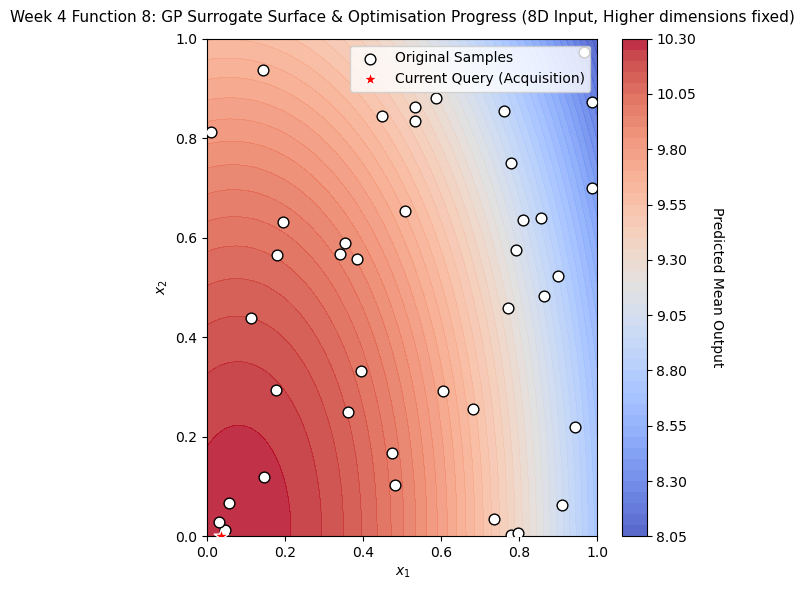

In [34]:
# =============================================================================
# Visualisation: Function 8 Surrogate Surface & Sample Points (Multi-Feature Safe)
# =============================================================================

gp_model = gp8            # GP model for Function 8
inputs = f8_inputs        # Input samples for Function 8
current_query = query_F8  # Current query for Function 8

plt.figure(figsize=(6, 6))

# Check how many features the GP expects
n_features = gp_model.n_features_in_ if hasattr(gp_model, 'n_features_in_') else inputs.shape[1]

# Create a dense grid over the first two dimensions [0, 1] x [0, 1]
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

if n_features > 2:
    # If there are more than 2 features, hold any extra dimensions constant 
    # (using the current query values if available, otherwise the training mean)
    fixed_vals = current_query[2:] if current_query is not None and len(current_query) > 2 else inputs[:, 2:].mean(axis=0)
    
    grid_cols = [xx.ravel(), yy.ravel()]
    for val in fixed_vals:
        grid_cols.append(np.full(xx.size, val))
    grid_points = np.column_stack(grid_cols)
    title_suffix = f" ({n_features}D Input, Higher dimensions fixed)"
else:
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    title_suffix = ""

# Predict using the fitted GP model for Function 8
mu_grid, sigma_grid = gp_model.predict(grid_points, return_std=True)
mu_grid_2d = mu_grid.reshape(xx.shape)

# Plot the predicted output surface
contour = plt.contourf(xx, yy, mu_grid_2d, levels=50, cmap='coolwarm', alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Mean Output', rotation=270, labelpad=20)

# 1. Plot initial training/sample points (projected to the first 2 dimensions)
plt.scatter(
    inputs[:, 0], inputs[:, 1], 
    color='white', edgecolor='black', s=60, label='Original Samples', zorder=3
)

# 2. Highlight the current query (projected to the first 2 dimensions)
if current_query is not None:
    plt.scatter(
        current_query[0], current_query[1], 
        color='red', edgecolor='white', s=120, marker='*', label='Current Query (Acquisition)', zorder=5
    )

plt.title(f'Week 4 Function 8: GP Surrogate Surface & Optimisation Progress{title_suffix}', fontsize=11, pad=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Week 4 Query Summary

| Function | Week 4 Query |
|---|---|
| 1 — Radiation field (2D) | 0.513943, 0.454749 |
| 2 — Noisy log-likelihood (2D) | 0.729589, 0.938148 |
| 3 — Drug discovery (3D) | 0.375610, 0.057061, 0.589980 |
| 4 — Warehouse business (4D) | 0.424125, 0.404716, 0.487507, 0.367688 |
| 5 — Chemical process (4D) | 0.269378, 0.810637, 0.999999, 0.999999 |
| 6 — Cake recipe (5D) | 0.344063, 0.007363, 0.627449, 0.999999, 0.004891 |
| 7 — ML hyperparameters (6D) | 0.012357, 0.162903, 0.399853, 0.082758, 0.249752, 0.923732 |
| 8 — Unspecified field (8D) | 0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000 |

These are the queries submitted for Week 4, taken directly from each section's final acquisition step above.

# Week 4 Fidelity Metrics — Mimicry of Black-Box Predictions

For each function, this compares the surrogate model's own prediction at the Week 4 query point (from that function's candidate-selection cell above) against the true black-box value returned for that query — i.e. how well each surrogate mimicked the black box at the point it recommended.

- **Abs./Rel. Error**: `predicted - true`, in the model's native (raw) output space.
- **Sigma / Z-score**: the GP's own predicted uncertainty at that point, and `error / sigma`. `|Z| >= 2` flags a query where the GP was overconfident (the true value fell outside where its own uncertainty said it plausibly would). Models without an uncertainty estimate (Polynomial, SVR, MLP) show `n/a`.
- **F1 and F7's GP** were fit on transformed outputs (`log10` and `log1p` respectively) to tame scale/skew, so sigma and Z-score for those two rows are computed in that same transformed space rather than the raw-space error — that's the space their uncertainty estimate actually applies to. F1's transform also loses sign, so its relative error isn't meaningful there; Z-score is the better read.

In [35]:
import pandas as pd

# =============================================================================
# Week 4 Fidelity Metrics — Mimicry of Black-Box Predictions
# =============================================================================
# For each function, compares the surrogate model's own prediction at the Week 4 query point
#     (taken from that function's candidate-selection cell above) against the true black-box value returned for that query.
# Two GPs (F1, F7) were fit on a transformed output (log10 and log1p respectively)
#    to tame skew/scale; for those, sigma and the z-score are computed in that same transformed space,
#    since that's the space the GP's own uncertainty estimate applies to. 
# Models with no uncertainty estimate (Polynomial, SVR, MLP) get "n/a" for sigma/z-score.


true_vals = {
    1: -3.89e-08, 2: 0.48756338, 3: -0.119425, 4: -0.991595077,
    5: 2699.10449, 6: -0.837299826, 7: 1.088040794, 8: 9.760083673,
}

# (function, model, predicted value, sigma [None if n/a],
#  z-score error override [None -> use pred-true directly])
records = [
    (1, "GP (log10 space, sign lost)", 10**(-54.0877), 32.9510, -54.0877 - np.log10(abs(true_vals[1]) + 1e-300)),
    (2, "GP",                          0.613,          0.068,   None),
    (3, "GP",                         -0.065596,        0.070476, None),
    (3, "Polynomial",                  0.052692,        None,    None),
    (4, "GP",                         -0.3717,          0.6813,  None),
    (5, "GP",                          537.32,          396.14,  None),
    (5, "SVR",                         1219.37,          None,    None),
    (6, "GP",                         -0.4621,          0.2455,  None),
    (7, "GP (expm1 of log1p pred)",    np.expm1(1.2173), 0.1587, 1.2173 - np.log1p(true_vals[7])),
    (7, "MLP",                         2.6923,           None,    None),
    (8, "GP",                          10.2789,          0.2181,  None),
    (8, "MLP",                         10.4813,          None,    None),
]

rows = []
for fn, model, pred, sigma, z_err in records:
    true_val = true_vals[fn]
    abs_err = pred - true_val
    rel_err = np.nan if abs(true_val) < 1e-6 else abs(abs_err) / abs(true_val) * 100
    if sigma is None:
        z = np.nan
    else:
        z = (z_err if z_err is not None else abs_err) / sigma
    if rel_err != rel_err:      # NaN check
        fidelity = "See note"
    elif rel_err < 10:
        fidelity = "Excellent"
    elif rel_err < 30:
        fidelity = "Good"
    elif rel_err < 60:
        fidelity = "Poor"
    else:
        fidelity = "Very poor"
    rows.append([fn, model, pred, true_val, abs_err, rel_err, sigma, z, fidelity])

fidelity_df = pd.DataFrame(
    rows,
    columns=["Function", "Model", "Predicted", "True Value", "Abs. Error",
             "Rel. Error (%)", "Sigma", "Z-score", "Fidelity"]
)

def fmt(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "n/a"
    if x != 0 and abs(x) < 1e-3:
        return f"{x:.4e}"
    return f"{x:,.4f}"

display_df = fidelity_df.copy()
for c in ["Predicted", "True Value", "Abs. Error", "Rel. Error (%)", "Sigma", "Z-score"]:
    display_df[c] = display_df[c].apply(fmt)

print("=" * 110)
print("Week 4 Fidelity Metrics (Mimicry of Black-Box Predictions)")
print("=" * 110)
print(display_df.to_string(index=False))
print("\nNote: F1's GP was fit on log10(|output|) (sign lost, rel. error not meaningful) and")
print("F7's GP on log1p(output); sigma/Z-score for those two rows are in that transformed space.")
print("Rows with |Z| >= 2 indicate the GP's uncertainty estimate was overconfident at that point.")

Week 4 Fidelity Metrics (Mimicry of Black-Box Predictions)
 Function                       Model  Predicted  True Value  Abs. Error Rel. Error (%)    Sigma Z-score  Fidelity
        1 GP (log10 space, sign lost) 8.1715e-55 -3.8900e-08  3.8900e-08            n/a  32.9510 -1.4166  See note
        2                          GP     0.6130      0.4876      0.1254        25.7272   0.0680  1.8447      Good
        3                          GP    -0.0656     -0.1194      0.0538        45.0735   0.0705  0.7638      Poor
        3                  Polynomial     0.0527     -0.1194      0.1721       144.1214      n/a     n/a Very poor
        4                          GP    -0.3717     -0.9916      0.6199        62.5149   0.6813  0.9099 Very poor
        5                          GP   537.3200  2,699.1045 -2,161.7845        80.0927 396.1400 -5.4571 Very poor
        5                         SVR 1,219.3700  2,699.1045 -1,479.7345        54.8232      n/a     n/a      Poor
        6            